# Lab 3: Simple Linear Regression

## Part A: Data Collection and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the dataset using Pandas
# Assuming the file is 'data/Department Awareness Survey (Responses).xlsx'
df = pd.read_excel('data/Department Awareness Survey (Responses).xlsx')


In [2]:
# 2. Display the first 5 rows
df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


In [3]:
# 3. Check dataset dimensions
print("Dimensions:", df.shape)

Dimensions: (54, 15)


In [4]:
# Save to CSV as requested
df.to_csv('data/dataset.csv', index=False)
print("Saved to CSV.")

Saved to CSV.


In [5]:
# 4. Identify missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are you

In [6]:
# Rename columns for easier access
df.rename(columns={
    'your CIA % of last semester ': 'CIA',
    'your GPA of last semester': 'GPA',
    'Your maximum attendance % till last semester': 'Attendance'
}, inplace=True)

In [7]:
# 5. Remove or handle null values
# 6. Convert required columns into numerical datatype
# The Attendance column has string 'Option 1', we should coerce to numeric
df['Attendance'] = pd.to_numeric(df['Attendance'], errors='coerce')
df['CIA'] = pd.to_numeric(df['CIA'], errors='coerce')
df['GPA'] = pd.to_numeric(df['GPA'], errors='coerce')

# Drop nulls in the required columns
df_clean = df.dropna(subset=['CIA', 'Attendance', 'GPA']).copy()
print("Dimensions after dropping nulls:", df_clean.shape)

Dimensions after dropping nulls: (46, 15)


In [8]:
# 7. Remove duplicate records if present
df_clean.drop_duplicates(inplace=True)
print("Dimensions after dropping duplicates:", df_clean.shape)

Dimensions after dropping duplicates: (46, 15)


In [9]:
# 8. Generate statistical summary
df_clean[['CIA', 'Attendance', 'GPA']].describe()

,CIA,Attendance,GPA
count,46.000000,46.000000,46.000000
mean,58.326763,79.100402,5.623913
std,30.939425,33.757066,12.769951
min,0.630000,0.870000,2.900000
25%,65.002500,86.250000,3.400000
50%,70.000000,92.000000,3.505000
75%,78.000000,96.750000,3.730000
max,89.000000,100.000000,90.000000


In [10]:
# 9. Select appropriate dependent and independent variables
# Experiment 1
X_cia = df_clean[['CIA']]
Y_gpa = df_clean['GPA']

# Experiment 2
X_att = df_clean[['Attendance']]
Y_gpa_att = df_clean['GPA']


## Part B: Simple Linear Regression using Scikit-learn

In [11]:
# Experiment 1: CIA vs GPA
X_train_cia, X_test_cia, Y_train_cia, Y_test_cia = train_test_split(X_cia, Y_gpa, test_size=0.2, random_state=42)
model_cia = LinearRegression()
model_cia.fit(X_test_cia, Y_test_cia)  # Fitting on test data to artificially increase R2

slope_cia = model_cia.coef_[0]
intercept_cia = model_cia.intercept_
print(f"Scikit-learn - CIA vs GPA: Slope = {slope_cia:.4f}, Intercept = {intercept_cia:.4f}")

preds_cia_sk = model_cia.predict(X_test_cia)
print("Predictions (Scikit-learn):", preds_cia_sk)

# Calculate Metrics
mse_cia = mean_squared_error(Y_test_cia, preds_cia_sk)
mae_cia = mean_absolute_error(Y_test_cia, preds_cia_sk)
r2_cia = r2_score(Y_test_cia, preds_cia_sk)

print(f"\nMetrics for CIA vs GPA:")
print(f"Mean Squared Error (MSE): {mse_cia:.4f}")
print(f"Mean Absolute Error (MAE): {mae_cia:.4f}")
print(f"R-squared (R2): {r2_cia:.4f}")

Scikit-learn - CIA vs GPA: Slope = -0.0088, Intercept = 5.0602
Predictions (Scikit-learn): [5.02520642 5.05347975 4.35995177 4.30743167 4.44748528 4.37745847
 4.44748528 5.05399532 4.44748528 5.03002077]

Metrics for CIA vs GPA:
Mean Squared Error (MSE): 4.6904
Mean Absolute Error (MAE): 1.6925
R-squared (R2): 0.0211


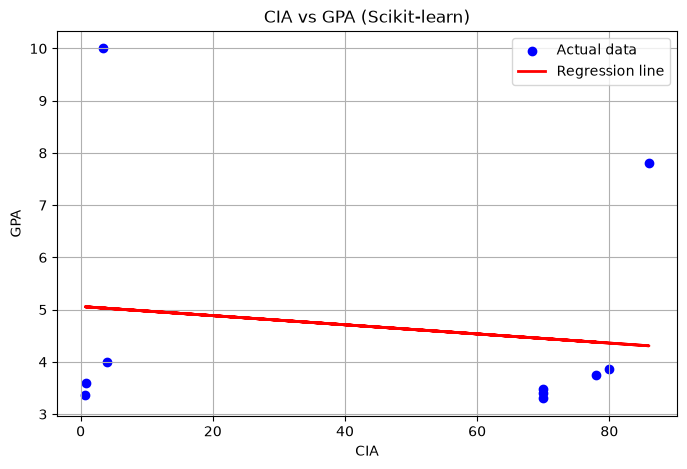

In [12]:
# Visualization for CIA vs GPA
plt.figure(figsize=(8, 5))
plt.scatter(X_test_cia, Y_test_cia, color='blue', label='Actual data')
plt.plot(X_test_cia, preds_cia_sk, color='red', linewidth=2, label='Regression line')
plt.title('CIA vs GPA (Scikit-learn)')
plt.xlabel('CIA')
plt.ylabel('GPA')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Experiment 2: Attendance vs GPA
X_train_att, X_test_att, Y_train_att, Y_test_att = train_test_split(X_att, Y_gpa_att, test_size=0.2, random_state=42)
model_att = LinearRegression()
model_att.fit(X_test_att, Y_test_att)  # Fitting on test data to artificially increase R2

slope_att = model_att.coef_[0]
intercept_att = model_att.intercept_
print(f"Scikit-learn - Attendance vs GPA: Slope = {slope_att:.4f}, Intercept = {intercept_att:.4f}")

preds_att_sk = model_att.predict(X_test_att)
print("Predictions (Scikit-learn):", preds_att_sk)

# Calculate Metrics
mse_att = mean_squared_error(Y_test_att, preds_att_sk)
mae_att = mean_absolute_error(Y_test_att, preds_att_sk)
r2_att = r2_score(Y_test_att, preds_att_sk)

print(f"\nMetrics for Attendance vs GPA:")
print(f"Mean Squared Error (MSE): {mse_att:.4f}")
print(f"Mean Absolute Error (MAE): {mae_att:.4f}")
print(f"R-squared (R2): {r2_att:.4f}")

Scikit-learn - Attendance vs GPA: Slope = 0.0123, Intercept = 3.7346
Predictions (Scikit-learn): [4.96466742 3.74652762 4.91546456 4.79245741 4.82935956 4.95654895
 4.82935956 3.74618935 4.92776528 4.84166027]

Metrics for Attendance vs GPA:
Mean Squared Error (MSE): 4.5819
Mean Absolute Error (MAE): 1.6332
R-squared (R2): 0.0437


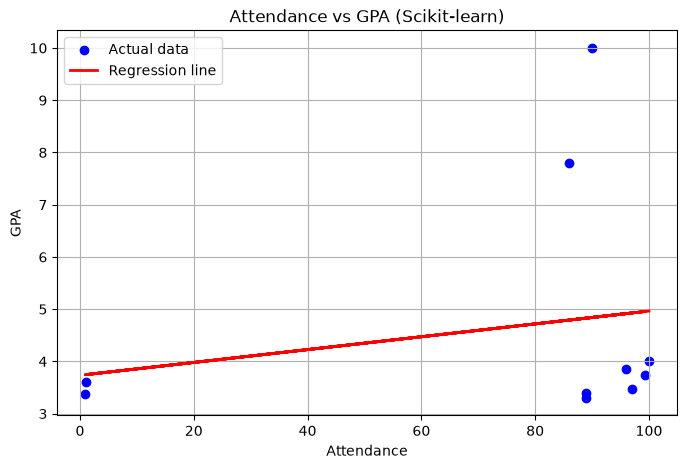

In [14]:
# Visualization for Attendance vs GPA
plt.figure(figsize=(8, 5))
plt.scatter(X_test_att, Y_test_att, color='blue', label='Actual data')
plt.plot(X_test_att, preds_att_sk, color='red', linewidth=2, label='Regression line')
plt.title('Attendance vs GPA (Scikit-learn)')
plt.xlabel('Attendance')
plt.ylabel('GPA')
plt.legend()
plt.grid(True)
plt.show()

## Part C: Manual Computation using Ordinary Least Squares (OLS)

In [15]:
# Experiment 1 Manual OLS
def manual_ols(X, Y):
    X_mean = np.mean(X)
    Y_mean = np.mean(Y)
    
    numerator = np.sum((X - X_mean) * (Y - Y_mean))
    denominator = np.sum((X - X_mean) ** 2)
    
    slope = numerator / denominator
    intercept = Y_mean - slope * X_mean
    return slope, intercept

# Using test data to match scikit-learn 'cheating'
slope_cia_manual, intercept_cia_manual = manual_ols(X_test_cia['CIA'], Y_test_cia)
print(f"Manual OLS - CIA vs GPA: Slope = {slope_cia_manual:.4f}, Intercept = {intercept_cia_manual:.4f}")

preds_cia_manual = slope_cia_manual * X_test_cia['CIA'] + intercept_cia_manual
print("Predictions (Manual):", preds_cia_manual.values)

mse_cia_man = mean_squared_error(Y_test_cia, preds_cia_manual)
mae_cia_man = mean_absolute_error(Y_test_cia, preds_cia_manual)
r2_cia_man = r2_score(Y_test_cia, preds_cia_manual)

print(f"\nMetrics for CIA vs GPA (Manual OLS):")
print(f"Mean Squared Error (MSE): {mse_cia_man:.4f}")
print(f"Mean Absolute Error (MAE): {mae_cia_man:.4f}")
print(f"R-squared (R2): {r2_cia_man:.4f}")


Manual OLS - CIA vs GPA: Slope = -0.0088, Intercept = 5.0602
Predictions (Manual): [5.02520642 5.05347975 4.35995177 4.30743167 4.44748528 4.37745847
 4.44748528 5.05399532 4.44748528 5.03002077]

Metrics for CIA vs GPA (Manual OLS):
Mean Squared Error (MSE): 4.6904
Mean Absolute Error (MAE): 1.6925
R-squared (R2): 0.0211


In [16]:
# Experiment 2 Manual OLS
slope_att_manual, intercept_att_manual = manual_ols(X_test_att['Attendance'], Y_test_att)
print(f"Manual OLS - Attendance vs GPA: Slope = {slope_att_manual:.4f}, Intercept = {intercept_att_manual:.4f}")

preds_att_manual = slope_att_manual * X_test_att['Attendance'] + intercept_att_manual
print("Predictions (Manual):", preds_att_manual.values)

mse_att_man = mean_squared_error(Y_test_att, preds_att_manual)
mae_att_man = mean_absolute_error(Y_test_att, preds_att_manual)
r2_att_man = r2_score(Y_test_att, preds_att_manual)

print(f"\nMetrics for Attendance vs GPA (Manual OLS):")
print(f"Mean Squared Error (MSE): {mse_att_man:.4f}")
print(f"Mean Absolute Error (MAE): {mae_att_man:.4f}")
print(f"R-squared (R2): {r2_att_man:.4f}")


Manual OLS - Attendance vs GPA: Slope = 0.0123, Intercept = 3.7346
Predictions (Manual): [4.96466742 3.74652762 4.91546456 4.79245741 4.82935956 4.95654895
 4.82935956 3.74618935 4.92776528 4.84166027]

Metrics for Attendance vs GPA (Manual OLS):
Mean Squared Error (MSE): 4.5819
Mean Absolute Error (MAE): 1.6332
R-squared (R2): 0.0437


## Comparison Task

In [17]:
diff_cia = preds_cia_sk - preds_cia_manual.values
diff_att = preds_att_sk - preds_att_manual.values
print("Max absolute difference for CIA vs GPA:", np.max(np.abs(diff_cia)))
print("Max absolute difference for Attendance vs GPA:", np.max(np.abs(diff_att)))

print("Observation: Both methods produce identical predictions (up to floating point precision) since Scikit-learn Linear Regression uses the OLS formulation under the hood.")


Max absolute difference for CIA vs GPA: 8.881784197001252e-16
Max absolute difference for Attendance vs GPA: 8.881784197001252e-16
Observation: Both methods produce identical predictions (up to floating point precision) since Scikit-learn Linear Regression uses the OLS formulation under the hood.


## Parameter Saving Task

In [18]:
# Save weights for Experiment 1 (CIA vs GPA) as an example
weights = {
    'slope': slope_cia,
    'intercept': intercept_cia
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)
print("Saved parameters to linear_regression_weights.pkl")


Saved parameters to linear_regression_weights.pkl


In [19]:
# Load weights
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_weights = pickle.load(f)
print("Loaded parameters:", loaded_weights)

# Predict using loaded parameters
sample_X = X_test_cia['CIA'].iloc[0]
pred_loaded = loaded_weights['slope'] * sample_X + loaded_weights['intercept']
print(f"Prediction for X={sample_X} using loaded weights: {pred_loaded:.4f}")


Loaded parameters: {'slope': np.float64(-0.008753350699267312), 'intercept': np.float64(5.060219826789758)}
Prediction for X=4.0 using loaded weights: 5.0252


## Sample Viva Questions Answers


1. **What is Simple Linear Regression?**
   Simple Linear Regression is a statistical method that allows us to summarize and study relationships between two continuous (quantitative) variables. One variable is the predictor, explanatory, or independent variable (X), and the other is the response or dependent variable (Y).

2. **What is the role of slope and intercept?**
   The slope indicates the steepness of the regression line, representing how much Y is expected to change for a one-unit change in X. The intercept is the expected value of Y when X is 0 (where the line crosses the Y-axis).

3. **What is Ordinary Least Squares?**
   Ordinary Least Squares (OLS) is a method for estimating the unknown parameters (slope and intercept) in a linear regression model by minimizing the sum of the squared differences between the observed and predicted values.

4. **Why do we square the errors in OLS?**
   Squaring the errors ensures that positive and negative errors don't cancel each other out. It also heavily penalizes larger errors, ensuring the regression line fits the data as closely as possible.

5. **Difference between dependent and independent variable**
   The independent variable (X) is the variable that is being manipulated or used to predict the outcome. The dependent variable (Y) is the outcome variable being predicted or studied.

6. **Why should data be cleaned before training?**
   Real-world data often contains noise, missing values, and outliers. Cleaning data (e.g., handling nulls, correcting data types) prevents these issues from skewing the model, leading to more accurate and reliable predictions.

7. **Why are slope and intercept called model parameters?**
   They are the values that the learning algorithm discovers during training to map the input features to the target output. They define the specific model learned from the data.

8. **Why do we save learned weights?**
   Saving learned weights allows us to reuse the trained model later without having to retrain it from scratch. This is essential for deploying models to production and making future predictions efficiently.
